# **Problem Statement**

# **Business Context**

Customer churn occurs when customers stop using a company’s products or services. High churn reduces revenue, increases customer-acquisition costs, and makes long-term growth more difficult.

This project analyzes customer information and service usage patterns to identify factors associated with churn. A machine-learning model is developed to predict customers who are likely to leave. These predictions can help businesses take early action through personalized offers, improved support, loyalty programs, and targeted retention strategies.

# **Objective**

The objective of this project is to:

- Analyze customer demographics, account details, and service usage patterns.
- Identify the factors that contribute to customer churn.
- Build a machine-learning model to predict customers likely to leave.
- Evaluate model performance using suitable classification metrics.
- Help the business take proactive customer-retention actions.
- Reduce churn, improve customer satisfaction, and increase long-term revenue.

# **Data Descripition**

The dataset contains customer information used to analyze and predict customer churn. It may include:

- **Customer demographics:** Gender, senior-citizen status, and dependents.
- **Account details:** Tenure, contract type, billing method, and payment method.
- **Services used:** Internet service, phone service, online security, backup, and technical support.
- **Financial information:** Monthly charges and total charges.
- **Churn:** The target variable indicating whether a customer left the company.

The data is used to identify patterns associated with churn and build a classification model that predicts whether a customer is likely to leave.

# **Installing and Importing Necessary Libraries**

In [2]:
!pip install matplotlib seaborn scikit-learn pandas

This command installs the libraries needed for data analysis, visualization, and machine learning:

```python
!pip install matplotlib seaborn scikit-learn pandas
```

- `matplotlib`: Creates charts and plots.
- `seaborn`: Creates statistical visualizations.
- `scikit-learn`: Provides classification models, train-test splitting, preprocessing, and evaluation metrics.
- `pandas`: Loads, cleans, and analyzes tabular data.

The `!` allows the notebook to run a terminal command. Running this cell ensures the required packages are installed before executing the churn-prediction analysis.

In [21]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.tree import plot_tree



This code imports the libraries required for data analysis, visualization, preprocessing, and machine learning:

- `pandas`: Loads and manipulates tabular data.
- `numpy`: Performs numerical and array-based calculations.
- `matplotlib.pyplot`: Creates charts and plots.
- `seaborn`: Creates statistical visualizations.
- `LinearRegression`: Provides a linear regression model.
- `mean_squared_error`, `r2_score`: Evaluate regression models.
- `train_test_split`: Splits data into training and testing sets.
- `StandardScaler`: Standardizes numerical features.
- `OneHotEncoder`: Converts categorical values into numerical form.
- `plot_tree`: Displays the structure of decision-tree-based models.

For this churn classification project, the regression imports (`LinearRegression`, `mean_squared_error`, and `r2_score`) are not required unless you plan to run regression analysis.

# **Loading the data**

The dataset is loaded from a CSV file using pandas and stored in the variable data.This creates a pandas DataFrame containing customer information used for churn analysis and prediction. The loaded data can then be examined using data.head(), data.shape, and data.info().

In [23]:
data=pd.read_csv(r"C:\Users\acer\OneDrive\Desktop\GEN AI\Machine Learning\Churn Prediction (1).csv")

This code loads the churn dataset from a CSV file into a pandas DataFrame:

```python
data = pd.read_csv(
    r"C:\Users\acer\OneDrive\Desktop\GEN AI\Churn Prediction (1).csv"
)
```

- `pd.read_csv()` reads the CSV file.
- `data` stores the dataset as a pandas DataFrame.
- The `r` before the file path creates a raw string, so Windows backslashes are interpreted correctly.
- The dataset can now be explored using commands such as `data.head()`, `data.shape`, `data.info()`, and `data.describe()`.

The file path is specific to your computer, so the code will only work if the CSV exists at that location.

# **Data Overview**

The data overview examines the structure and quality of the churn dataset:

- `data.shape` shows the number of customers and variables.
- `data.describe()` summarizes numerical columns such as age, credit limit, transaction amount, and utilization ratio.
- `data.head()` displays the first records to verify that the data loaded correctly.
- `data.tail()` displays the final records and confirms the dataset’s end.
- `data.info()` shows column names, data types, non-null values, and memory usage.

This step helps identify missing values, incorrect data types, unusual values, and the variables available for churn analysis and modeling.

In [27]:
data.shape

(10127, 21)

`data.shape` returns the dimensions of the DataFrame as:

```text
(number_of_rows, number_of_columns)
```

- The first value is the number of customer records.
- The second value is the number of variables or columns.

For example:

```text
(10127, 23)
```

means the dataset contains **10,127 customer records** and **23 columns**. This helps confirm the dataset size before performing analysis and building the churn-prediction model.

In [28]:
data.describe()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


`data.describe()` generates summary statistics for the dataset’s numerical columns.

It typically displays:

- **count:** Number of non-null values.
- **mean:** Average value.
- **std:** Standard deviation, showing data spread.
- **min:** Smallest value.
- **25%:** First quartile.
- **50%:** Median value.
- **75%:** Third quartile.
- **max:** Largest value.

For this churn dataset, it helps analyze variables such as customer age, credit limit, transaction amount, revolving balance, and utilization ratio. It can reveal typical customer behavior, differences in scale, unusual values, and possible outliers before preprocessing and model training.

In [29]:
data.tail()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
10122,772366833,Existing Customer,50,M,2,Graduate,Single,$40K - $60K,Blue,40,...,2,3,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462
10123,710638233,Attrited Customer,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,...,2,3,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511
10124,716506083,Attrited Customer,44,F,1,High School,Married,Less than $40K,Blue,36,...,3,4,5409.0,0,5409.0,0.819,10291,60,0.818,0.000
10125,717406983,Attrited Customer,30,M,2,Graduate,Unknown,$40K - $60K,Blue,36,...,3,3,5281.0,0,5281.0,0.535,8395,62,0.722,0.000
10126,714337233,Attrited Customer,43,F,2,Graduate,Married,Less than $40K,Silver,25,...,2,4,10388.0,1961,8427.0,0.703,10294,61,0.649,0.189


`data.tail()` displays the last five rows of the DataFrame by default.

It is used to:

- Confirm that the dataset loaded completely.
- Inspect the final customer records.
- Verify the column structure and data types visually.
- Detect unusual, missing, or incorrectly formatted values near the end of the dataset.

You can display a different number of final rows by using, for example, `data.tail(10)`.

In [30]:
data.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


`data.head()` displays the first five rows of the DataFrame by default.

It is used to:

- Confirm that the dataset loaded correctly.
- View the column names and their arrangement.
- Inspect sample customer records.
- Check whether values appear correctly formatted.
- Detect obvious missing or unusual values.

You can display more initial records with `data.head(10)`.

In [31]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  str    
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  str    
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  str    
 6   Marital_Status            10127 non-null  str    
 7   Income_Category           10127 non-null  str    
 8   Card_Category             10127 non-null  str    
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_Revolving_B

`data.info()` displays a concise technical summary of the DataFrame.

It shows:

- The total number of rows and columns.
- Each column name.
- The number of non-null values in each column.
- The data type of each column, such as integer, floating-point, or object.
- The approximate memory used by the DataFrame.

For this churn dataset, it helps identify missing values, confirm that columns have suitable data types, and determine which categorical variables require encoding before model training.

In [32]:
cat_columns= ['Attrition_Flag','Gender','Education_Level','Marital_Status','Income_Category'
              ,'Card_Category','Total_Relationship_Count','Months_Inactive_12_mon','Contacts_Count_12_mon',
              'Dependent_count']
num_columns=['Customer_Age','Months_on_book','Credit_Limit','Total_Revolving_Bal','Avg_Open_To_Buy',
             'Total_Amt_Chng_Q4_Q1','Total_Trans_Amt','Avg_Utilization_Ratio']

This code divides the dataset columns into two lists for exploratory data analysis:

```python
cat_columns = [
    'Attrition_Flag', 'Gender', 'Education_Level', 'Marital_Status',
    'Income_Category', 'Card_Category', 'Total_Relationship_Count',
    'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Dependent_count'
]

num_columns = [
    'Customer_Age', 'Months_on_book', 'Credit_Limit',
    'Total_Revolving_Bal', 'Avg_Open_To_Buy',
    'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
    'Avg_Utilization_Ratio'
]
```

- `cat_columns` contains categorical or discrete variables. These are suitable for count plots and category comparisons.
- `num_columns` contains numerical variables. These are suitable for histograms, boxplots, and summary statistics.
- `Attrition_Flag` is the target variable showing whether a customer remained or left.
- These lists allow loops to apply the appropriate visualization or analysis to each type of variable.

# **UNIVARIATE ANALYSIS**

Univariate analysis examines one variable at a time to understand its distribution and behavior.

In this notebook:

- Categorical variables are analyzed using count plots to compare customer categories and attrition levels.
- Numerical variables are analyzed using boxplots to examine their spread, median, and possible outliers.
- The analysis helps identify dominant customer groups, imbalanced categories, unusual numerical values, and potential patterns related to attrition.
- These findings support data cleaning, feature selection, and preparation for churn-prediction modeling.

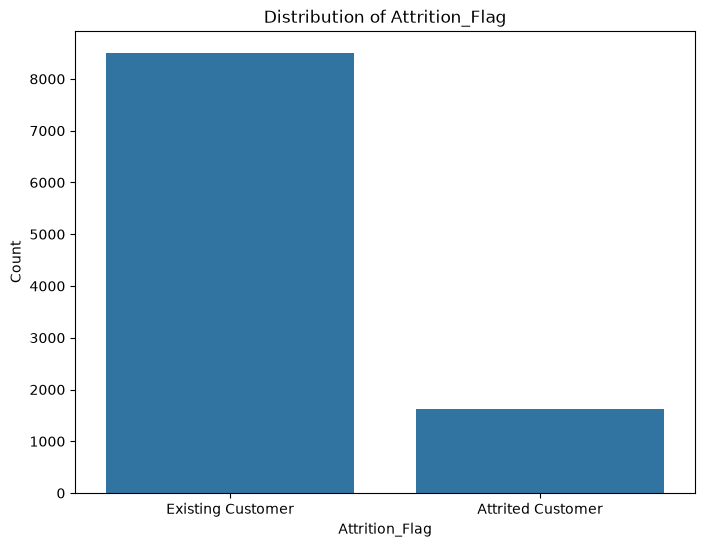

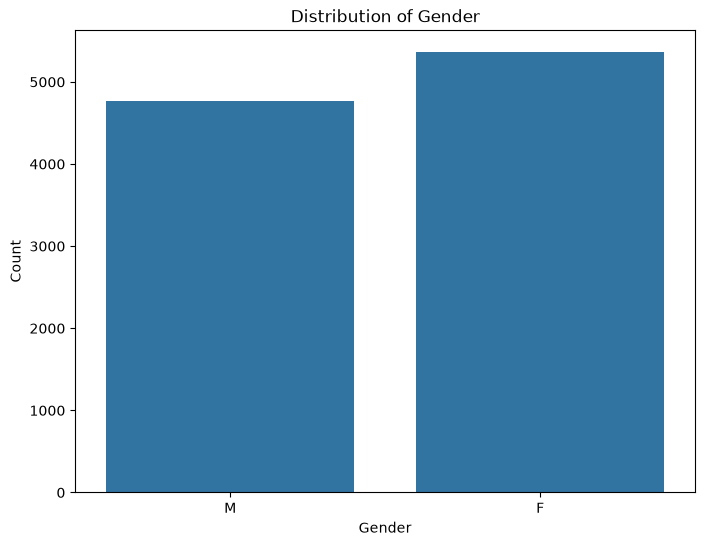

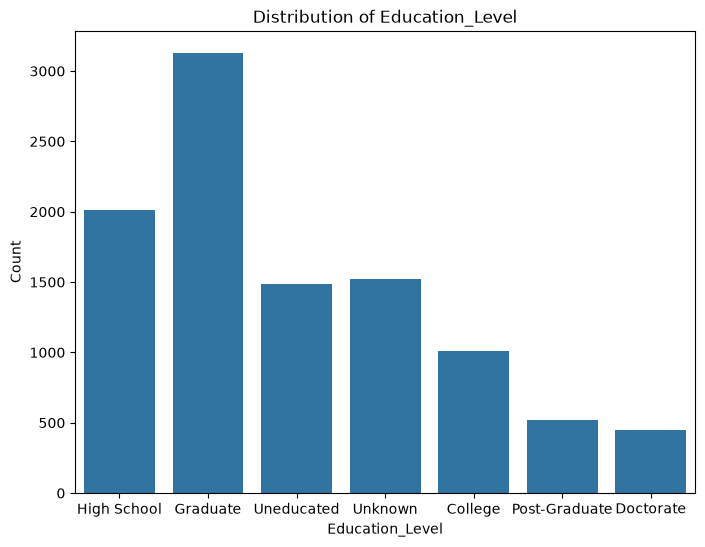

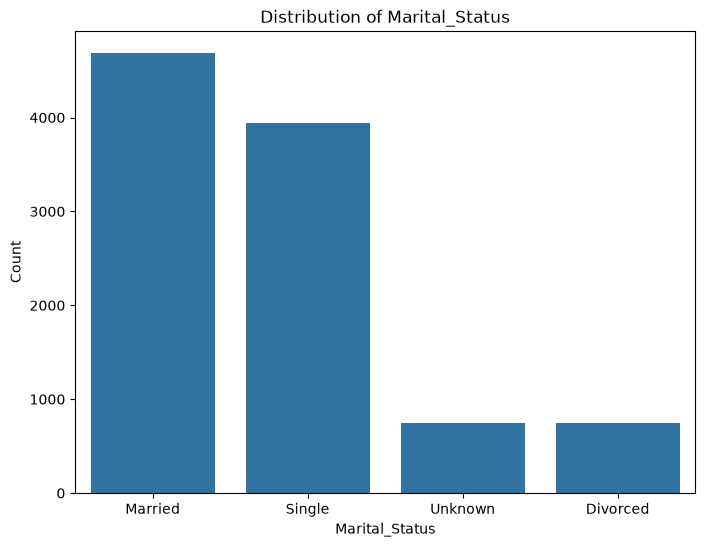

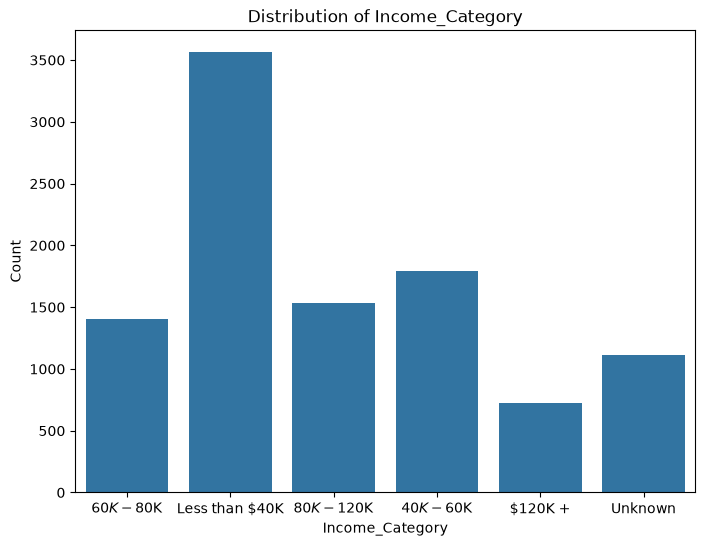

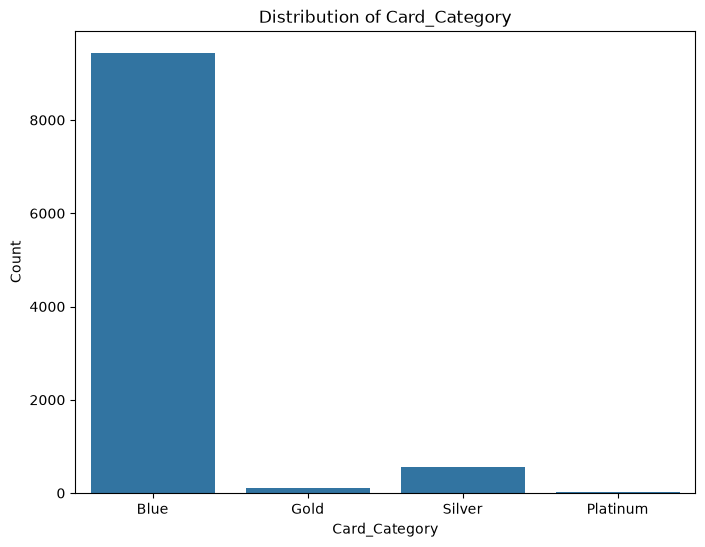

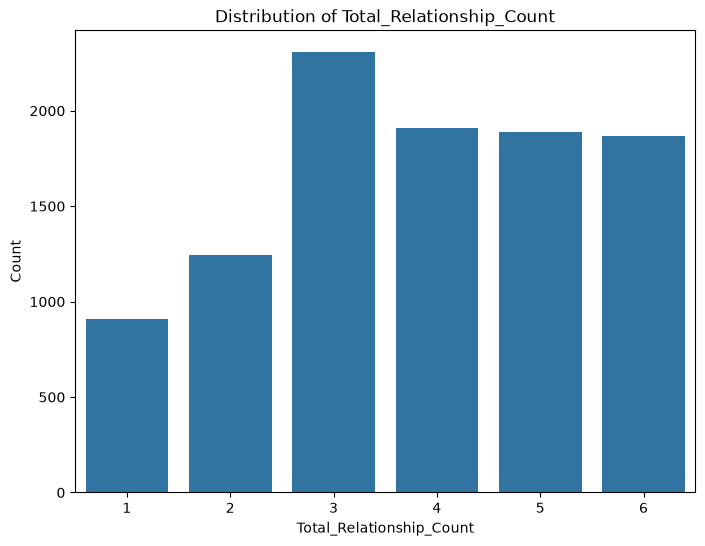

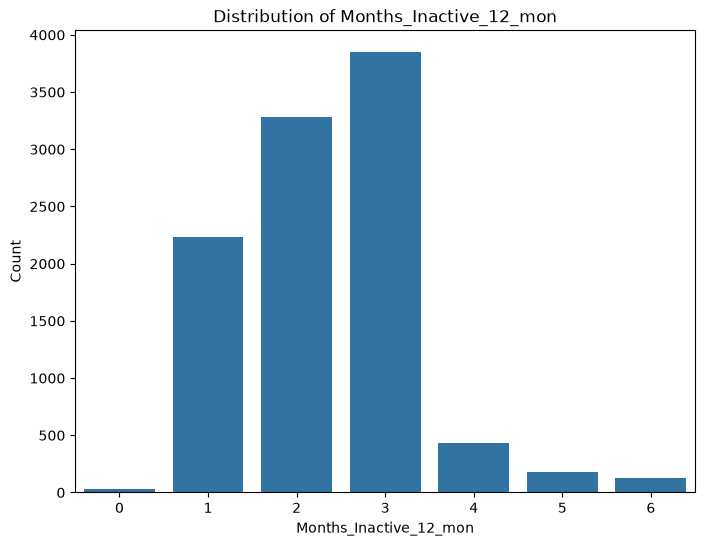

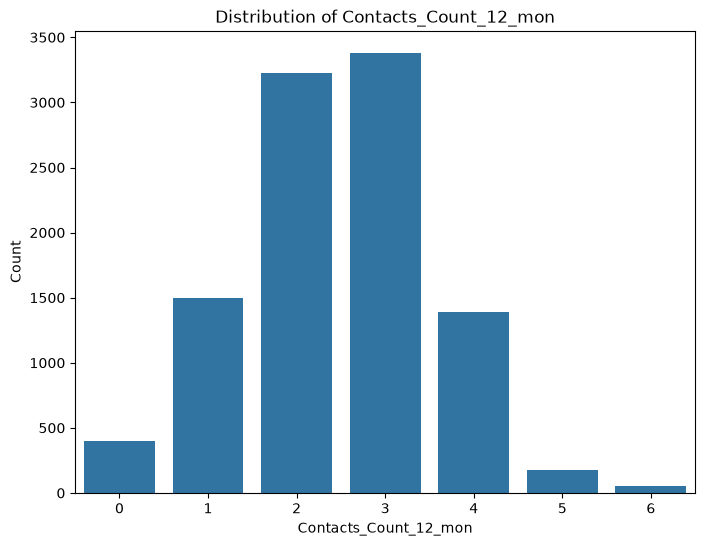

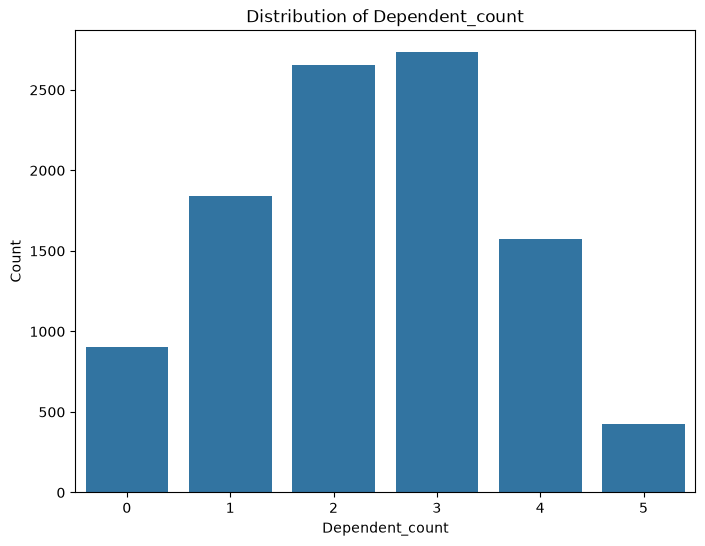

In [33]:
for col in cat_columns:
    plt.figure(figsize=(8,6))
    sns.countplot(x=col, data=data) 
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

This loop creates a separate count plot for every column in `cat_columns`:

```python
for col in cat_columns:
    plt.figure(figsize=(8, 6))
    sns.countplot(x=col, data=data)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()
```

- The loop selects each categorical column one at a time.
- `sns.countplot()` counts how many records belong to each category.
- Each chart shows the category distribution on the x-axis and the number of customers on the y-axis.
- The plots help identify dominant categories, imbalanced groups, and the distribution of attrited versus existing customers.
- `plt.show()` displays each chart separately.

This is useful for understanding customer profiles before performing bivariate analysis and model training.

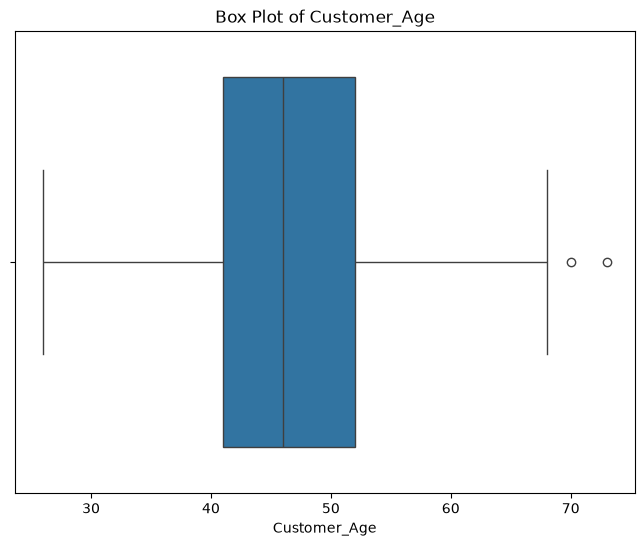

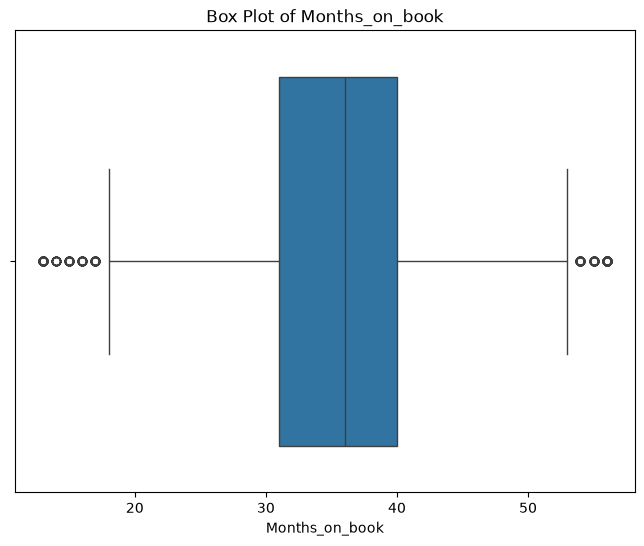

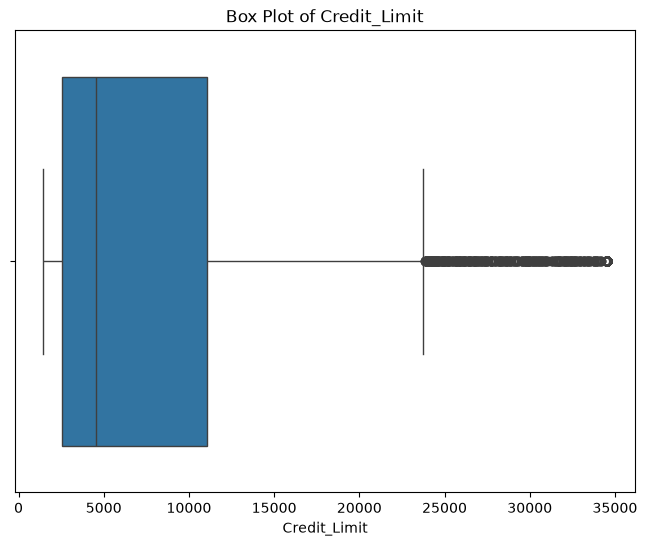

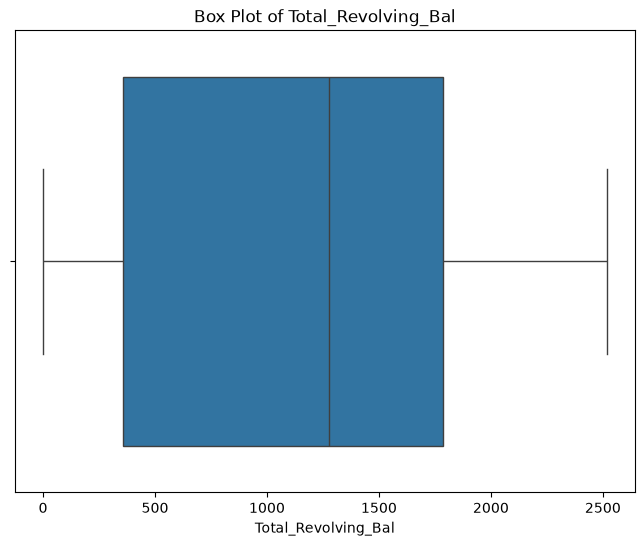

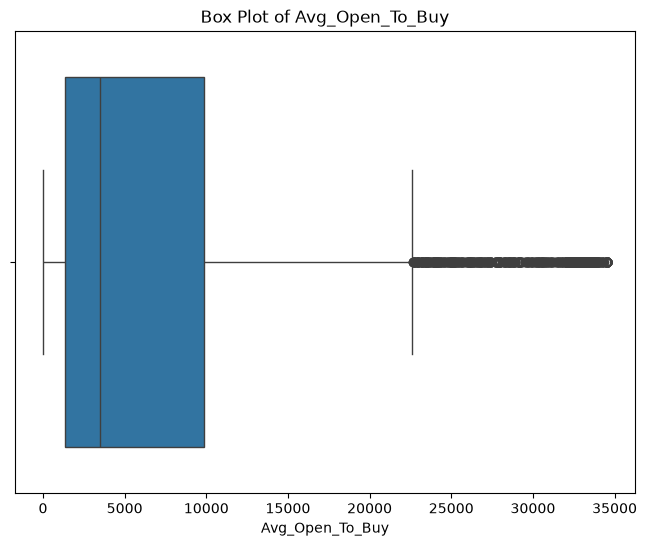

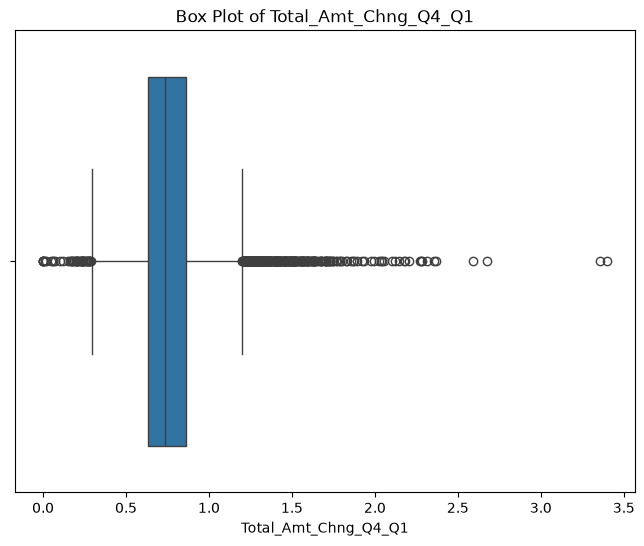

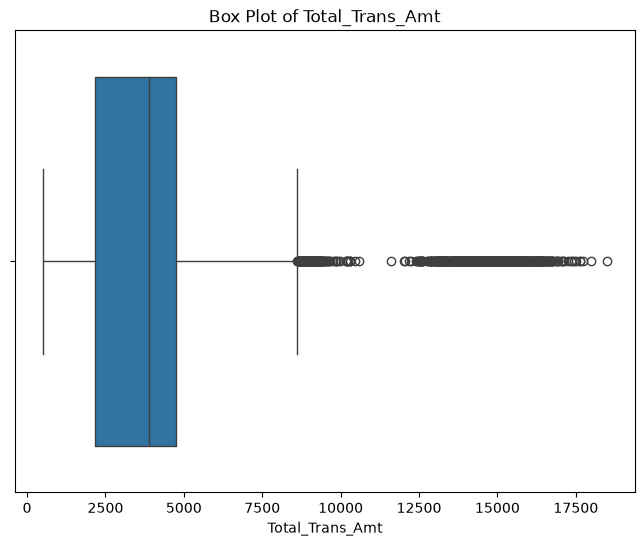

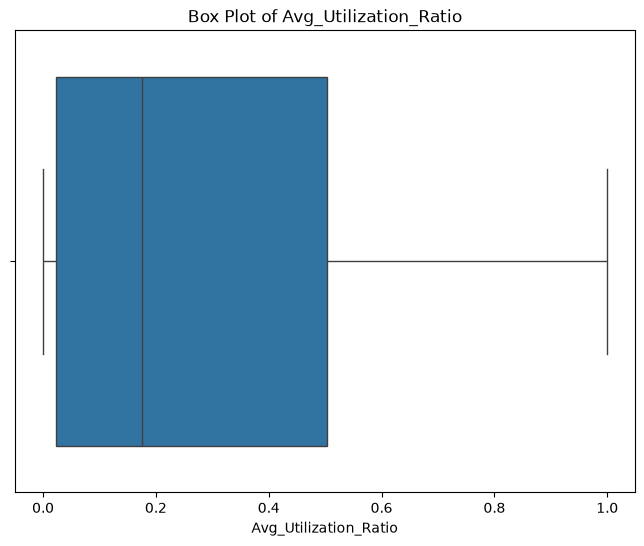

In [34]:
for column in num_columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=data[column])
    plt.title(f'Box Plot of {column}')
    plt.xlabel(column)
    plt.show()

This loop creates a boxplot for each numerical column:

```python
for column in num_columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=data[column])
    plt.title(f'Box Plot of {column}')
    plt.xlabel(column)
    plt.show()
```

- The loop processes each numerical variable individually.
- `sns.boxplot()` displays the distribution of values.
- The box shows the middle 50% of observations.
- The line inside the box represents the median.
- The whiskers show the typical data range.
- Points beyond the whiskers may indicate outliers.
- These plots help identify spread, skewness, unusually large or small values, and potential data-quality issues before modeling.

# **BIVARIATE ANALYSIS**

Bivariate analysis examines the relationship between two variables at a time.

In this notebook, it is used to:

- Compare customer age across attrition groups.
- Analyze attrition rates by gender, income category, education level, and card category.
- Compare transaction amounts and credit limits between existing and attrited customers.
- Examine whether months of inactivity is associated with attrition.
- Identify differences between customer groups using boxplots, count plots, and bar charts.

This analysis helps reveal relationships between customer characteristics and attrition, supporting feature selection and churn-prediction modeling.

In [35]:
plt.figure(figsize=(8, 6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

```python
plt.figure(figsize=(8, 6))
```

This creates a new Matplotlib figure for the next chart.

- `figsize=(8, 6)` sets the figure size to 8 inches wide and 6 inches high.
- It provides enough space for labels, titles, and plotted data.
- This line does not draw any data by itself; the following plotting command uses this figure.

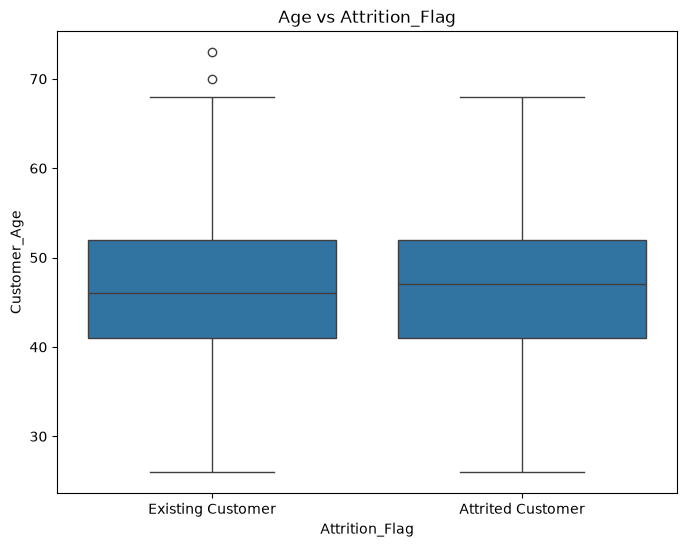

In [36]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Attrition_Flag', y='Customer_Age', data=data)
plt.title('Age vs Attrition_Flag')
plt.xlabel('Attrition_Flag')
plt.ylabel('Customer_Age')
plt.show()

This code creates a boxplot comparing customer age across attrition groups:

```python
plt.figure(figsize=(8, 6))
sns.boxplot(x='Attrition_Flag', y='Customer_Age', data=data)
plt.title('Age vs Attrition_Flag')
plt.xlabel('Attrition_Flag')
plt.ylabel('Customer_Age')
plt.show()
```

- The x-axis shows the customer status: existing or attrited.
- The y-axis shows customer age.
- Each box displays the median, middle 50% of ages, typical range, and possible outliers.
- Comparing the boxes shows whether attrited customers tend to be older or younger than existing customers.
- Similar distributions suggest age alone may not strongly explain attrition; noticeably different distributions suggest age may be a useful predictor.

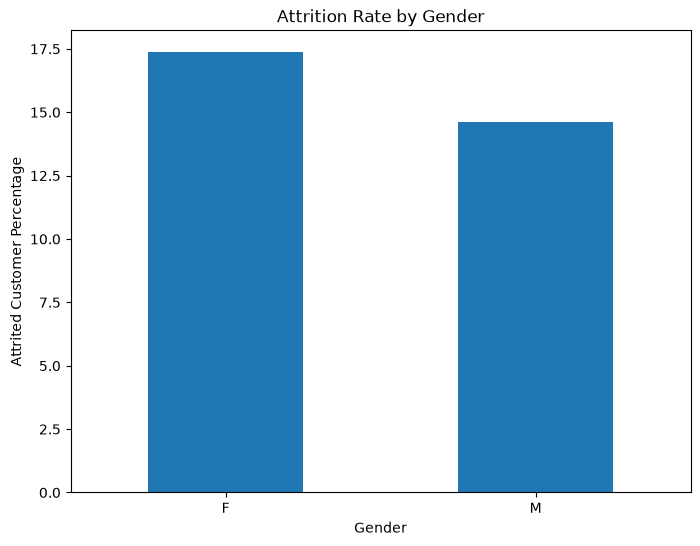

In [37]:
gender_attrition = data.groupby('Gender')['Attrition_Flag'].value_counts(normalize=True).unstack()
gender_attrition['Attrited Customer Percentage'] = gender_attrition['Attrited Customer'] * 100
gender_attrition= gender_attrition.sort_values(by='Attrited Customer Percentage', ascending=False)

#creating a bar plot to visualize the attrition
plt.figure(figsize=(8,6))
gender_attrition['Attrited Customer Percentage'].plot(kind='bar')
plt.title('Attrition Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Attrited Customer Percentage')
plt.xticks(rotation=0)
plt.show()

This code calculates and visualizes the attrition rate for each gender:

- `groupby('Gender')` separates customers by gender.
- `value_counts(normalize=True)` calculates the proportion of existing and attrited customers within each gender.
- `unstack()` converts the results into separate columns.
- The attrited-customer proportion is multiplied by `100` to create a percentage.
- The table is sorted from the highest to the lowest attrition rate.
- The bar chart compares attrition percentages across genders.

The gender with the taller bar has the higher attrition rate. This may indicate a relationship between gender and customer attrition, but it does not prove that gender causes attrition.

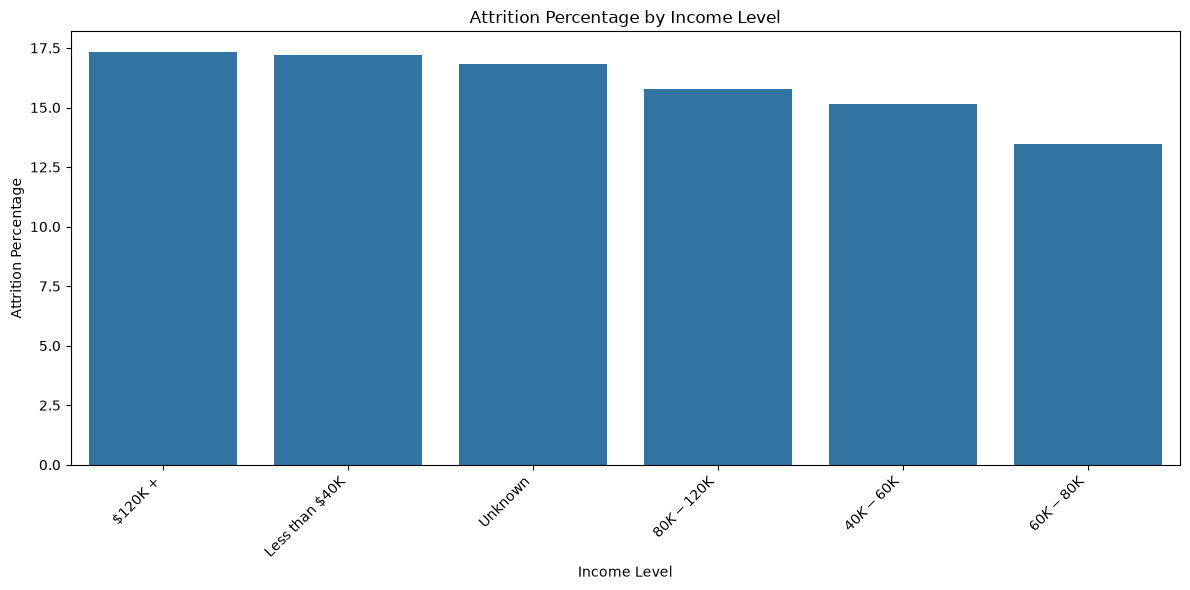

In [38]:
# Calculate the percentage of attrited customers for each income level
income_churn_counts = data.groupby(['Income_Category', 'Attrition_Flag'])['CLIENTNUM'].count().unstack()
income_churn_percentage = (income_churn_counts['Attrited Customer'] / (income_churn_counts['Attrited Customer'] + income_churn_counts['Existing Customer'])) * 100

# Create a DataFrame for the result and sort by percentage
churn_percentage_df = pd.DataFrame({'Percentage': income_churn_percentage}).sort_values('Percentage', ascending=False)

# Plotting the results
plt.figure(figsize=(12, 6))
sns.barplot(x=churn_percentage_df.index, y='Percentage', data=churn_percentage_df)
plt.title('Attrition Percentage by Income Level')
plt.xlabel('Income Level')
plt.ylabel('Attrition Percentage')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

This code calculates and visualizes the attrition percentage for each income category:

- `groupby()` groups customers by income level and attrition status.
- `count()` counts customers in each group.
- `unstack()` creates separate columns for attrited and existing customers.
- The attrition percentage is calculated as:

$$
\text{Attrition Rate}
=
\frac{\text{Attrited Customers}}
{\text{Attrited Customers}+\text{Existing Customers}}
\times 100
$$

- The results are stored in `churn_percentage_df` and sorted from highest to lowest attrition rate.
- The bar chart compares attrition rates across income categories.

A taller bar indicates a higher proportion of attrited customers in that income group. This helps identify income segments that may require targeted retention strategies. It shows association, not causation.

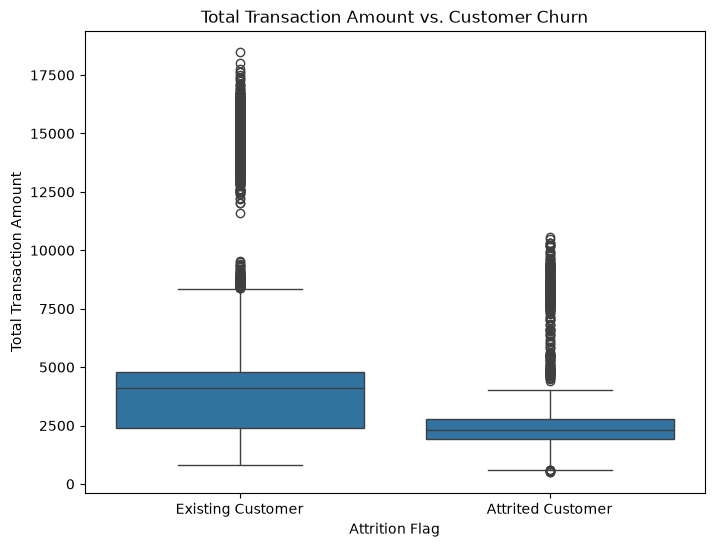

In [39]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Attrition_Flag', y='Total_Trans_Amt', data=data)
plt.title('Total Transaction Amount vs. Customer Churn')
plt.xlabel('Attrition Flag')
plt.ylabel('Total Transaction Amount')
plt.show()

This code creates a boxplot comparing total transaction amounts between existing and attrited customers:

- The x-axis shows the attrition status.
- The y-axis shows total transaction amount.
- Each box displays the median, middle 50% of values, typical range, and possible outliers.
- Comparing the groups shows whether attrited customers generally have higher or lower transaction amounts.
- A noticeably lower transaction amount for attrited customers may indicate reduced engagement before leaving.
- Differences suggest transaction activity could help predict attrition, but the plot shows association rather than causation.

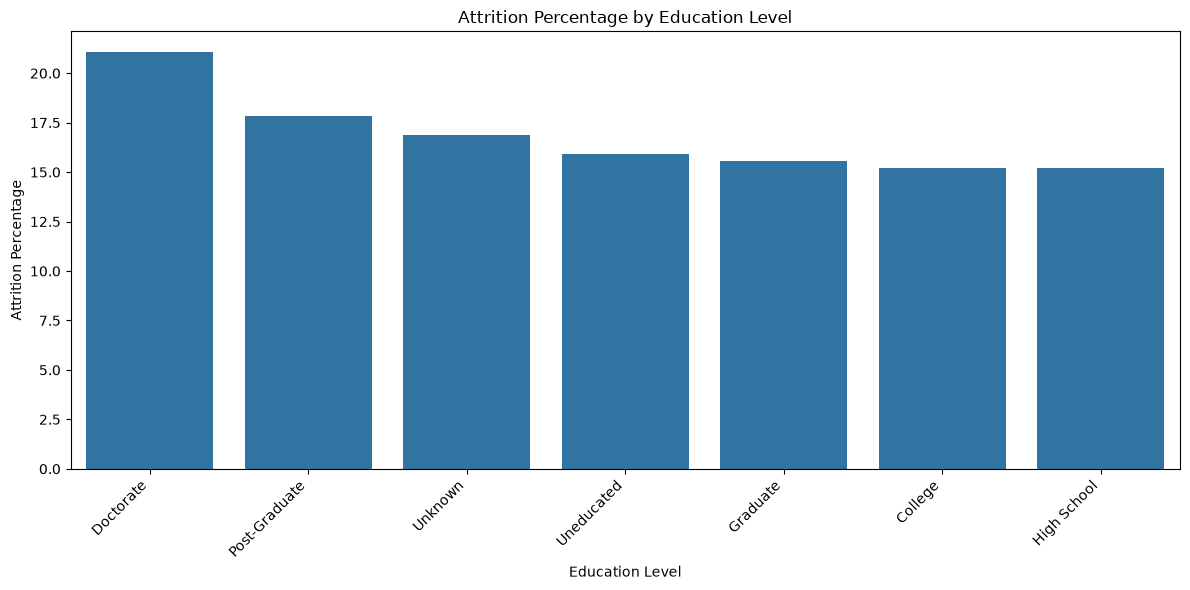

In [40]:
# Calculate the percentage of attrited customers for each education level
education_churn_counts = data.groupby(['Education_Level', 'Attrition_Flag'])['CLIENTNUM'].count().unstack()
education_churn_percentage = (education_churn_counts['Attrited Customer'] / (education_churn_counts['Attrited Customer'] + education_churn_counts['Existing Customer'])) * 100

# Create a DataFrame for the result and sort by percentage
churn_percentage_df = pd.DataFrame({'Percentage': education_churn_percentage}).sort_values('Percentage', ascending=False)

# Plotting the results
plt.figure(figsize=(12, 6))
sns.barplot(x=churn_percentage_df.index, y='Percentage', data=churn_percentage_df)
plt.title('Attrition Percentage by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Attrition Percentage')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

This code calculates and visualizes customer attrition rates by education level:

- Customers are grouped by `Education_Level` and `Attrition_Flag`.
- `count()` calculates the number of customers in each group.
- The attrition percentage is calculated as:

$$
\text{Attrition Rate}
=
\frac{\text{Attrited Customers}}
{\text{Attrited Customers}+\text{Existing Customers}}
\times 100
$$

- The education levels are sorted from the highest to the lowest attrition rate.
- The bar chart displays the comparison, with labels rotated for readability.

A taller bar indicates that a larger proportion of customers in that education group became attrited. This can help identify education segments for further investigation and targeted retention strategies, but it shows association rather than causation.

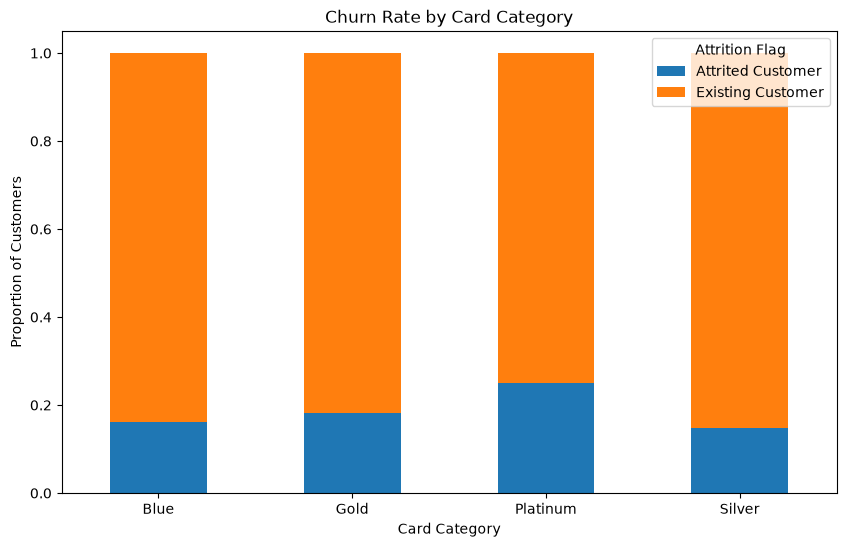

In [41]:
# Calculate the churn rate for each card category
churn_rates = data.groupby('Card_Category')['Attrition_Flag'].value_counts(normalize=True).unstack()

# Create the stacked bar chart
churn_rates.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Churn Rate by Card Category')
plt.xlabel('Card Category')
plt.ylabel('Proportion of Customers')
plt.xticks(rotation=0)
plt.legend(title='Attrition Flag')
plt.show()

This code calculates and visualizes the proportion of existing and attrited customers for each card category:

- Customers are grouped by `Card_Category`.
- `value_counts(normalize=True)` converts counts into proportions within each card category.
- `unstack()` creates separate columns for each attrition status.
- The stacked bar chart shows the composition of each card category.
- Each bar represents one card category and totals approximately `1.0` or `100%`.
- The attrited-customer segment shows the churn proportion for that card category.

Card categories with a larger attrited segment have higher churn rates. However, categories with few customers may produce unstable percentages, so group size should also be considered.

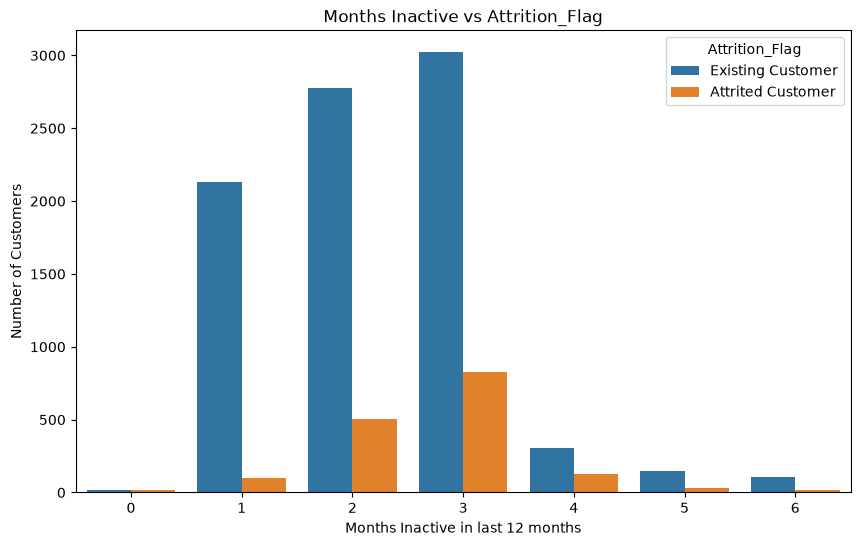

In [42]:
plt.figure(figsize=(10,6))
sns.countplot(x='Months_Inactive_12_mon', hue='Attrition_Flag', data=data)
plt.title('Months Inactive vs Attrition_Flag')
plt.xlabel('Months Inactive in last 12 months')
plt.ylabel('Number of Customers')
plt.show()

This code creates a count plot showing customer attrition by months of inactivity:

- The x-axis shows the number of inactive months during the last 12 months.
- The bars are separated by `Attrition_Flag`, comparing existing and attrited customers.
- The y-axis shows the number of customers in each group.
- Higher attrition counts at certain inactivity levels may indicate that reduced activity is associated with customer attrition.
- Comparing the proportions, rather than only the bar heights, is important because some inactivity levels may contain more customers overall.
- This relationship can help identify inactive customers who may benefit from targeted retention campaigns.

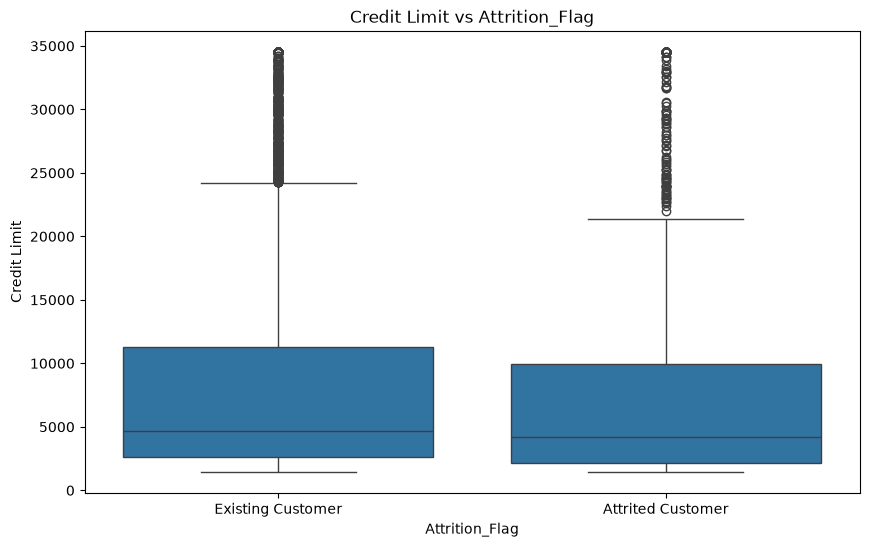

In [43]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Attrition_Flag', y='Credit_Limit', data=data)
plt.title('Credit Limit vs Attrition_Flag')
plt.xlabel('Attrition_Flag')
plt.ylabel('Credit Limit')
plt.show()

This code creates a boxplot comparing credit limits between existing and attrited customers:

- The x-axis shows the attrition status.
- The y-axis shows the customers’ credit limits.
- Each box displays the median, middle 50% of values, typical range, and possible outliers.
- Comparing the groups shows whether attrited customers tend to have higher or lower credit limits.
- Similar distributions suggest that credit limit alone may not strongly explain attrition.
- Noticeable differences may indicate that credit limit is useful for churn prediction, but the plot shows association rather than causation.

# **DATA PREPROCESSING**

Data preprocessing prepares the churn dataset for machine-learning models.

In this notebook, preprocessing includes:

- Removing the identifier column `CLIENTNUM`, because it does not provide meaningful predictive information.
- Checking the distribution of `Attrition_Flag`.
- Converting `Attrition_Flag` into numeric values:
  - `Existing Customer` → `0`
  - `Attrited Customer` → `1`
- Encoding education and income categories numerically.
- Applying one-hot encoding to categorical variables such as marital status, card category, and gender.
- Separating the target variable from the input features.

These steps ensure the dataset contains suitable numeric features for classification models.

In [44]:
data=data.drop(['CLIENTNUM'], axis=1)

```python
data = data.drop(['CLIENTNUM'], axis=1)
```

This removes the `CLIENTNUM` column from the DataFrame.

- `CLIENTNUM` is a customer identifier, not a meaningful behavioral feature.
- `axis=1` tells pandas to remove a column.
- The cleaned DataFrame is assigned back to `data`.

Removing this column prevents the model from treating customer IDs as predictive information and reduces unnecessary data.

In [45]:
data['Attrition_Flag'].value_counts()

Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

```python
data['Attrition_Flag'].value_counts()
```

This counts how many customers belong to each attrition category.

- `Existing Customer`: Customers who remained.
- `Attrited Customer`: Customers who left.
- The output helps measure class balance in the target variable.
- A much larger existing-customer count indicates class imbalance, which should be considered when evaluating the classification models.

This information also confirms that the attrition labels are present before converting them into numeric values.

In [46]:
# create a mapping for 'Attrition_flag'
attrition_mapping = {'Existing Customer': 0, 'Attrited Customer': 1}
# Use the mapp function to encode the 'Attrition_Flag' column
data['Attrition_Flag'] = data['Attrition_Flag'].map(attrition_mapping)

This code converts the text-based attrition labels into numeric values:

```python
attrition_mapping = {
    'Existing Customer': 0,
    'Attrited Customer': 1
}

data['Attrition_Flag'] = data['Attrition_Flag'].map(attrition_mapping)
```

- Existing customers are encoded as `0`.
- Attrited customers are encoded as `1`.
- `.map()` replaces each label using the mapping dictionary.
- Numeric encoding allows classification algorithms to use `Attrition_Flag` as the target variable.

Any unmatched or unexpected label becomes `NaN`, so the column should be checked after mapping.

In [47]:
data['Education_Level'].unique()

<StringArray>
[  'High School',      'Graduate',    'Uneducated',       'Unknown',
       'College', 'Post-Graduate',     'Doctorate']
Length: 7, dtype: str

```python
data['Education_Level'].unique()
```

This displays all distinct values in the `Education_Level` column.

It helps to:

- Identify the education categories present in the dataset.
- Check for unexpected spelling, capitalization, or formatting.
- Detect values such as `unknown` that require special handling.
- Confirm that the mapping dictionary includes every category before encoding.

The output is used to design an appropriate numeric mapping for machine-learning preprocessing.

In [48]:
education_mapping = {
    'Uneducated': 1,
    'High School': 2,
    'College': 3,
    'Graduate': 4,
    'Post-Graduate': 5,
    'Doctorate': 6,
    'unknown': 0  # Handling unknown values by assigning them a unique integer
}

data['Education_Level'] = data['Education_Level'].map(education_mapping)

This code converts education labels into numeric values:

```python
education_mapping = {
    'Uneducated': 1,
    'High School': 2,
    'College': 3,
    'Graduate': 4,
    'Post-Graduate': 5,
    'Doctorate': 6,
    'unknown': 0
}

data['Education_Level'] = data['Education_Level'].map(education_mapping)
```

- Each education category is replaced with a number.
- `unknown` is encoded as `0`.
- `.map()` applies the dictionary to the entire column.
- Numeric encoding makes the feature usable by machine-learning models.

Unrecognized category values become `NaN`, so the encoded column should be checked for missing values afterward.

In [49]:
data['Income_Category'].unique()

<StringArray>
[   '$60K - $80K', 'Less than $40K',   '$80K - $120K',    '$40K - $60K',
        '$120K +',        'Unknown']
Length: 6, dtype: str

```python
data['Income_Category'].unique()
```

This displays all distinct values in the `Income_Category` column.

It helps to:

- Identify the income groups present in the dataset.
- Check for unexpected values or spelling inconsistencies.
- Detect the `Unknown` category.
- Confirm that every category is included in the numeric mapping before encoding.

This validation helps prevent categories from becoming missing values during preprocessing.

In [50]:
income_category = {
    'Less than $40K': 1,
    '$40K - $60K': 2,
    '$60K - $80K': 3,
    '$80K - $120K': 4,
    '$120K +': 5,
    'Unknown': 0  # Handling unknown values by assigning them a unique integer
}

data['Income_Category'] = data['Income_Category'].map(income_category)

This code converts income-category labels into numeric values:

```python
income_category = {
    'Less than $40K': 1,
    '$40K - $60K': 2,
    '$60K - $80K': 3,
    '$80K - $120K': 4,
    '$120K +': 5,
    'Unknown': 0
}

data['Income_Category'] = data['Income_Category'].map(income_category)
```

- Each income range is replaced with a numeric code.
- `Unknown` is encoded as `0`.
- `.map()` applies the mapping to the entire column.
- Numeric values make the feature usable by machine-learning algorithms.

Any income label missing from the dictionary becomes `NaN`, so the column should be checked after encoding.

In [51]:
data = pd.get_dummies(data, columns=['Marital_Status', 'Card_Category'], drop_first=True, dtype=int)

```python
data = pd.get_dummies(
    data,
    columns=['Marital_Status', 'Card_Category'],
    drop_first=True,
    dtype=int
)
```

This converts the categorical columns `Marital_Status` and `Card_Category` into numeric dummy variables.

- `pd.get_dummies()` creates separate binary columns for each category.
- `drop_first=True` removes one category from each variable to avoid redundant columns and multicollinearity.
- `dtype=int` stores the values as `0` or `1`.
- The transformed DataFrame is assigned back to `data`.

For example, a card category may become columns such as `Card_Category_Gold` or `Card_Category_Platinum`, where `1` means the customer belongs to that category and `0` means they do not.

In [52]:
data = pd.get_dummies(data, columns=['Gender'], drop_first=True, dtype=int)

```python
data = pd.get_dummies(
    data,
    columns=['Gender'],
    drop_first=True,
    dtype=int
)
```

This converts the `Gender` column into a numeric dummy variable.

- `pd.get_dummies()` creates binary indicator columns.
- `drop_first=True` removes one gender category as the reference category.
- `dtype=int` stores the indicator values as `0` and `1`.
- The transformed data is saved back to `data`.

For example, if the remaining column is `Gender_M`, then `1` indicates male and `0` represents the reference category. This makes gender usable by the classification models.

In [53]:
data.head()

,Attrition_Flag,Customer_Age,Dependent_count,Education_Level,Income_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,...,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Marital_Status_Married,Marital_Status_Single,Marital_Status_Unknown,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver,Gender_M
0,0,45,3,2.0,3,39,5,1,3,12691.0,...,42,1.625,0.061,1,0,0,0,0,0,1
1,0,49,5,4.0,1,44,6,1,2,8256.0,...,33,3.714,0.105,0,1,0,0,0,0,0
2,0,51,3,4.0,4,36,4,1,0,3418.0,...,20,2.333,0.000,1,0,0,0,0,0,1
3,0,40,4,2.0,1,34,3,4,1,3313.0,...,20,2.333,0.760,0,0,1,0,0,0,0
4,0,40,3,1.0,3,21,5,1,0,4716.0,...,28,2.500,0.000,1,0,0,0,0,0,1


# **TRAIN TEST SPLIT**

In [54]:
data["Attrition_Flag"].value_counts()

Attrition_Flag
0    8500
1    1627
Name: count, dtype: int64

```python
data["Attrition_Flag"].value_counts()
```

After encoding, this counts the numeric target classes:

- `0`: Existing customers.
- `1`: Attrited customers.

The output shows how many records belong to each class and whether the target is balanced. If class `0` is much larger than class `1`, the dataset is imbalanced, so accuracy alone may be misleading. Precision, recall, and F1-score should also be considered.

In [55]:
y = data['Attrition_Flag']
X = data.drop('Attrition_Flag', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (7088, 23)
X_test shape: (3039, 23)
y_train shape: (7088,)
y_test shape: (3039,)


This code separates the target, splits the data, and checks the resulting dimensions:

```python
y = data['Attrition_Flag']
X = data.drop('Attrition_Flag', axis=1)
```

- `y` contains the target: `0` for existing customers and `1` for attrited customers.
- `X` contains all predictor features, excluding the target column.

```python
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)
```

- 70% of the records are used for training.
- 30% are used for testing.
- `random_state=42` makes the split reproducible.
- `stratify=y` preserves the same attrition-class proportions in both datasets.

The printed shapes confirm that the feature and target rows match correctly. `X_train` and `X_test` have two dimensions, while `y_train` and `y_test` are one-dimensional.

In [56]:
model_eval_results = pd.DataFrame(columns=['Model', 'Train_Accuracy', 'Train_Precision', 'Train_Recall', 'Test_F1', 'Test_Accuracy', 'Test_Precision', 'Test_Recall ' ,'Test_F1'])

This code creates an empty DataFrame for storing classification-model results:

```python
model_eval_results = pd.DataFrame(columns=[
    'Model',
    'Train_Accuracy',
    'Train_Precision',
    'Train_Recall',
    'Test_F1',
    'Test_Accuracy',
    'Test_Precision',
    'Test_Recall',
    'Test_F1'
])
```

The metrics measure:

- `Accuracy`: Overall percentage of correct predictions.
- `Precision`: Of predicted attrited customers, how many actually attrited.
- `Recall`: Of actual attrited customers, how many were detected.
- `F1`: Balance between precision and recall.
- `Train_*`: Performance on training data.
- `Test_*`: Performance on unseen testing data.

There are two issues in the current column list:

1. `Test_F1` appears twice.
2. `'Test_Recall '` contains an unwanted trailing space.

Use this corrected version:

```python
model_eval_results = pd.DataFrame(columns=[
    'Model',
    'Train_Accuracy',
    'Train_Precision',
    'Train_Recall',
    'Train_F1',
    'Test_Accuracy',
    'Test_Precision',
    'Test_Recall',
    'Test_F1'
])
```

This order also matches the values inserted later.

In [57]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

These imports provide the classification models and evaluation metrics:

- `accuracy_score`: Measures the proportion of correct predictions.
- `precision_score`: Measures how many predicted attrited customers were actually attrited.
- `recall_score`: Measures how many actual attrited customers were correctly detected.
- `f1_score`: Combines precision and recall into one balanced metric.
- `DecisionTreeClassifier`: Builds a rule-based tree classifier.
- `RandomForestClassifier`: Combines multiple decision trees for more stable predictions.
- `GradientBoostingClassifier`: Builds trees sequentially, with each tree improving previous errors.

These models are trained and compared using the classification metrics.

# Model 1

Model 1 uses a `DecisionTreeClassifier` to predict whether a customer will remain or become attrited.

A decision tree:

- Splits customers according to feature values.
- Creates decision rules in a tree structure.
- Assigns each customer to an `Existing Customer` or `Attrited Customer` class.
- Is easy to visualize and interpret.

Its performance is evaluated using accuracy, precision, recall, and F1-score. A large difference between training and testing performance may indicate overfitting, because an unrestricted decision tree can memorize the training data..testing metrics are therefore the most important for judging performance on new customers.

In [58]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_train_pred = dt_model.predict(X_train)
y_test_pred = dt_model.predict(X_test)

train_accuracy_dt = accuracy_score(y_train, y_train_pred)
train_precision_dt = precision_score(y_train, y_train_pred)
train_recall_dt = recall_score(y_train, y_train_pred)
train_f1_dt = f1_score(y_train, y_train_pred)

test_accuracy_dt = accuracy_score(y_test, y_test_pred)
test_precision_dt = precision_score(y_test, y_test_pred)
test_recall_dt = recall_score(y_test, y_test_pred)
test_f1_dt = f1_score(y_test, y_test_pred)

model_eval_results.loc[len(model_eval_results)] = ['Decision Tree', train_accuracy_dt, train_precision_dt, train_recall_dt, train_f1_dt, test_accuracy_dt, test_precision_dt, test_recall_dt, test_f1_dt]  
print(model_eval_results) 

           Model  Train_Accuracy  Train_Precision  Train_Recall  Test_F1  \
0  Decision Tree             1.0              1.0           1.0      1.0   

   Test_Accuracy  Test_Precision  Test_Recall    Test_F1  
0       0.933202        0.795031      0.786885  0.790937  


This code trains and evaluates a Decision Tree classifier:

```python
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
```

The model learns classification rules from the training data.

```python
y_train_pred = dt_model.predict(X_train)
y_test_pred = dt_model.predict(X_test)
```

These lines generate predictions for training and unseen testing data.

The following metrics evaluate the model:

- `Accuracy`: Percentage of all correct predictions.
- `Precision`: Percentage of predicted attrited customers who actually attrited.
- `Recall`: Percentage of actual attrited customers correctly identified.
- `F1`: Balance between precision and recall.

Both training and testing metrics are calculated to detect overfitting. A much higher training score than testing score suggests the tree memorized the training data.

Finally, the metrics are added to `model_eval_results` as a new row and printed for comparison with other models. Ensure the DataFrame columns follow the same order as the inserted values.

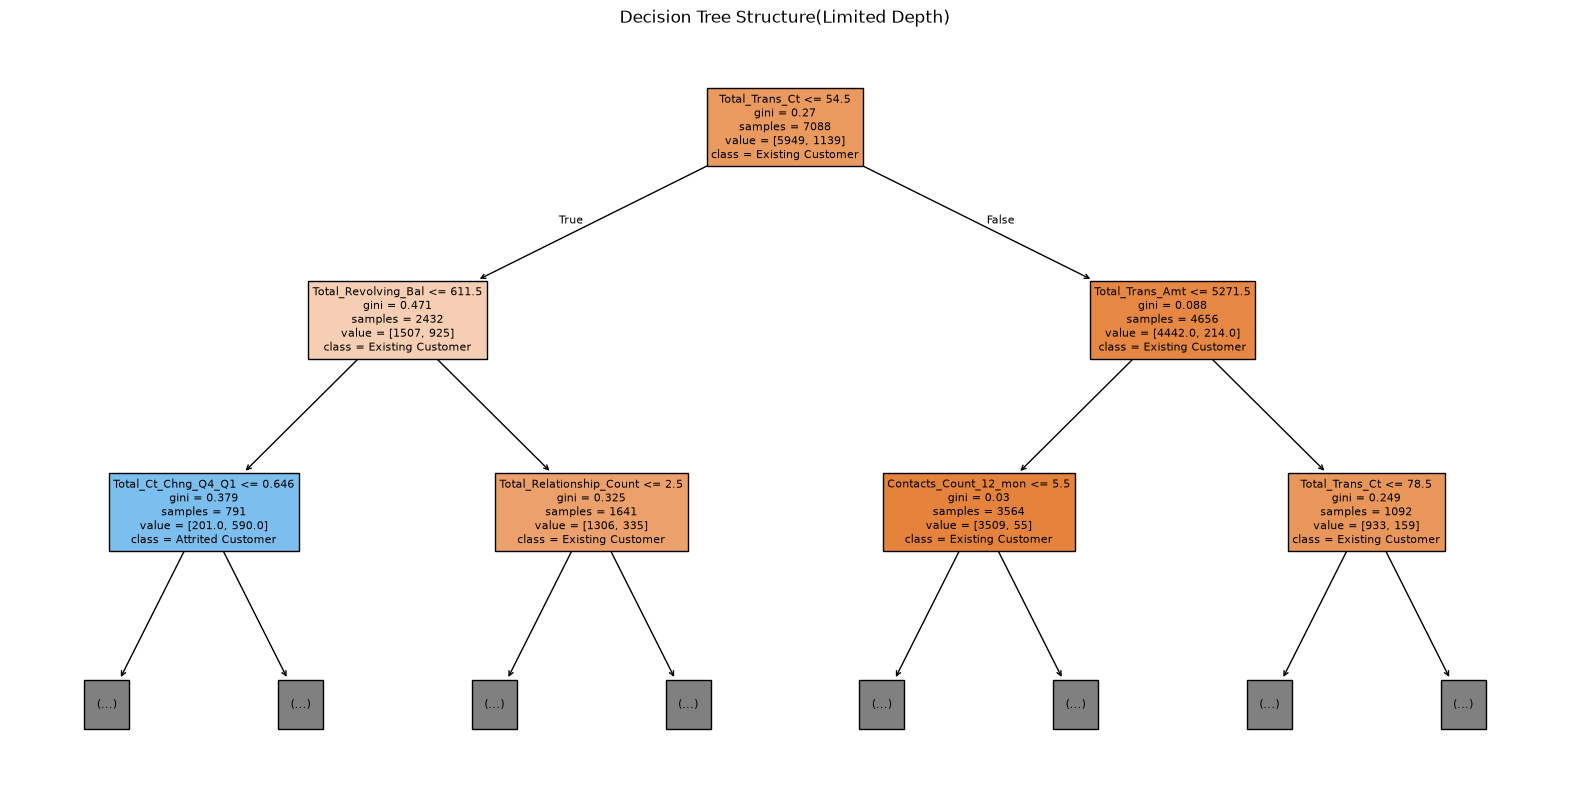

In [59]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(dt_model, filled=True, feature_names=X.columns, class_names=['Existing Customer', 'Attrited Customer'], max_depth=2)
plt.title("Decision Tree Structure(Limited Depth)")
plt.show()

This code visualizes the first two levels of the trained decision tree:

```python
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    filled=True,
    feature_names=X.columns,
    class_names=['Existing Customer', 'Attrited Customer'],
    max_depth=2
)
plt.title("Decision Tree Structure (Limited Depth)")
plt.show()
```

- `plot_tree()` displays the tree’s decision rules.
- `filled=True` colors nodes according to their predicted class.
- `feature_names=X.columns` shows the feature used at each split.
- `class_names` labels the two target classes.
- `max_depth=2` displays only the top two levels to keep the chart readable.
- Each node shows information such as the splitting rule, sample count, class distribution, and impurity.

This visualizes only a simplified portion of the tree; it does not limit the trained model itself.

# Model 2

Model 2 uses a `RandomForestClassifier` to predict customer attrition.

A random forest:

- Builds many decision trees.
- Trains each tree on different samples and feature combinations.
- Combines their predictions to produce a more stable result.
- Usually reduces overfitting compared with a single decision tree.
- Can capture nonlinear relationships between customer features and attrition.

Its performance is evaluated using accuracy, precision, recall, and F1-score on both training and testing data. The testing metrics are most important because they measure performance on unseen customers.

In [60]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_test_pred_rf = rf_model.predict(X_test)
y_train_pred_rf = rf_model.predict(X_train)

train_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)
train_precision_rf = precision_score(y_train, y_train_pred_rf)
train_recall_rf = recall_score(y_train, y_train_pred_rf)
train_f1_rf = f1_score(y_train, y_train_pred_rf)

test_accuracy_dt = accuracy_score(y_test, y_test_pred_rf)
test_precision_dt = precision_score(y_test, y_test_pred_rf)
test_recall_dt = recall_score(y_test, y_test_pred_rf)
test_f1_dt = f1_score(y_test, y_test_pred_rf)

model_eval_results.loc[len(model_eval_results)] = ['Random Forest', train_accuracy_rf, train_precision_rf, train_recall_rf, train_f1_rf, test_accuracy_dt, test_precision_dt, test_recall_dt, test_f1_dt]
print(model_eval_results)   

           Model  Train_Accuracy  Train_Precision  Train_Recall  Test_F1  \
0  Decision Tree             1.0              1.0           1.0      1.0   
1  Random Forest             1.0              1.0           1.0      1.0   

   Test_Accuracy  Test_Precision  Test_Recall    Test_F1  
0       0.933202        0.795031      0.786885  0.790937  
1       0.954590        0.914692      0.790984  0.848352  


This code trains and evaluates the **Random Forest model**:

```python
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
```

The model builds multiple decision trees using the training data.

```python
y_test_pred_rf = rf_model.predict(X_test)
y_train_pred_rf = rf_model.predict(X_train)
```

These lines generate predictions for training and testing customers.

The calculated metrics are:

- `Accuracy`: Overall correctness.
- `Precision`: Correctness of predicted attrited customers.
- `Recall`: Ability to detect actual attrited customers.
- `F1`: Balance between precision and recall.

The metrics are added to `model_eval_results` for comparison with the Decision Tree and Gradient Boosting models.

The variable names `test_accuracy_dt`, `test_precision_dt`, `test_recall_dt`, and `test_f1_dt` are misleading because they contain Random Forest results. Rename them to `test_accuracy_rf`, `test_precision_rf`, `test_recall_rf`, and `test_f1_rf` for clarity.

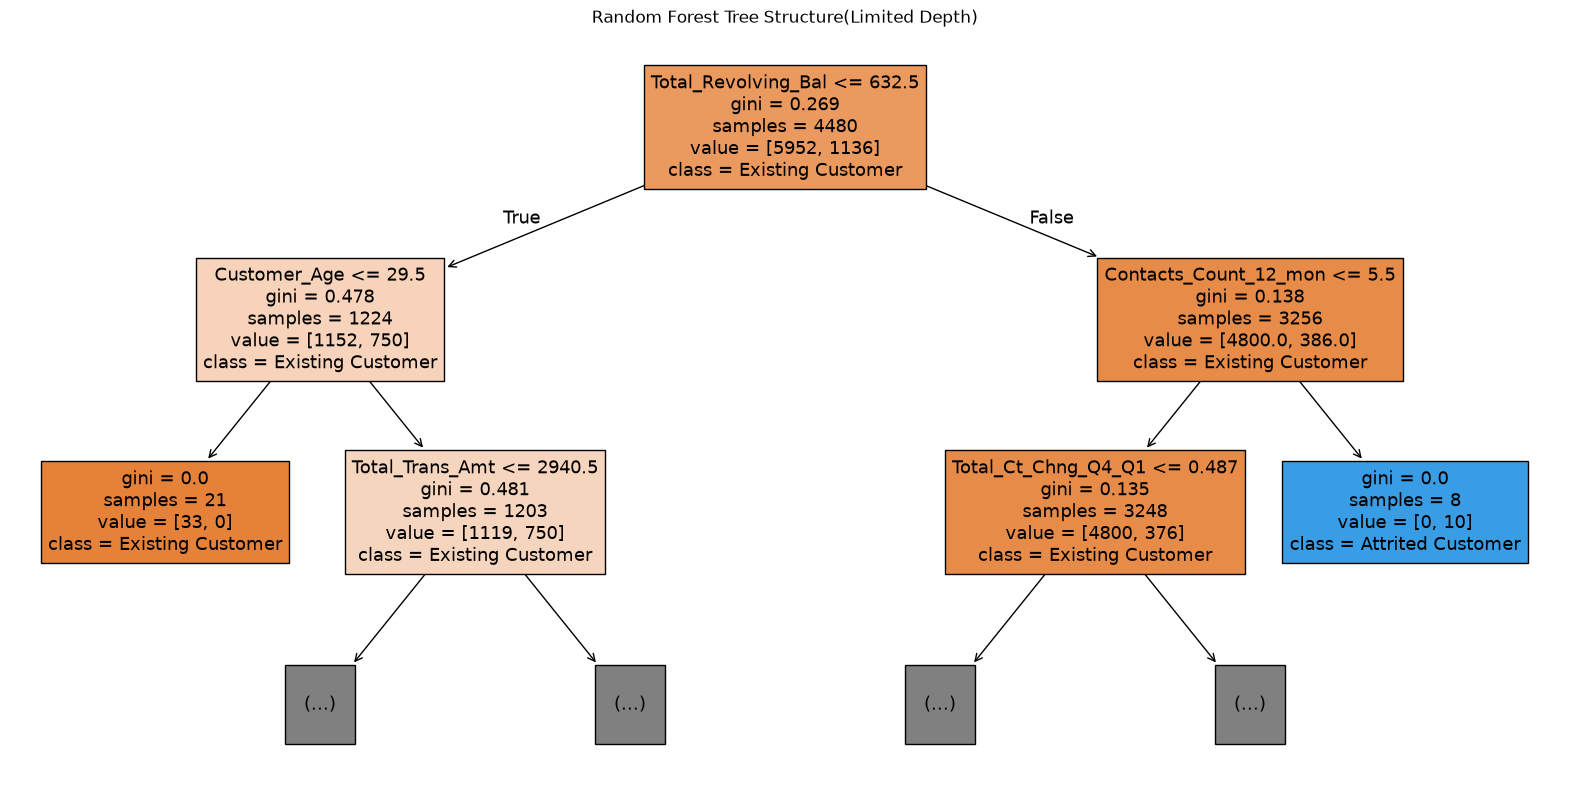

In [61]:
plt.figure(figsize=(20, 10))
plot_tree(rf_model.estimators_[0], filled=True, feature_names=X.columns, class_names=['Existing Customer', 'Attrited Customer'], max_depth=2)
plt.title("Random Forest Tree Structure(Limited Depth)")    
plt.show()

This code visualizes the first decision tree inside the Random Forest:

```python
plt.figure(figsize=(20, 10))
plot_tree(
    rf_model.estimators_[0],
    filled=True,
    feature_names=X.columns,
    class_names=['Existing Customer', 'Attrited Customer'],
    max_depth=2
)
plt.title("Random Forest Tree Structure (Limited Depth)")
plt.show()
```

- `rf_model.estimators_[0]` selects the first tree in the forest.
- `filled=True` colors nodes according to their predicted class.
- `feature_names=X.columns` displays the feature used at each split.
- `class_names` labels the two customer classes.
- `max_depth=2` displays only the first two levels for readability.
- The chart shows one tree’s decision rules, not the complete Random Forest. The final forest prediction combines results from all trees.

# Model 3

Model 3 uses a `GradientBoostingClassifier` to predict customer attrition.

Gradient Boosting:

- Builds decision trees sequentially.
- Each new tree focuses on correcting errors made by previous trees.
- Combines all trees into a stronger predictive model.
- Can capture complex, nonlinear relationships between customer features and attrition.

Evaluate it using accuracy, precision, recall, and F1-score on both training and testing data. The testing metrics are most important because they show how well the model generalizes to unseen customers. A large gap between training and testing scores may indicate overfitting.

In [70]:

gb_model = GradientBoostingClassifier(random_state=42)

# Impute missing feature values using medians calculated from the training set
train_medians = X_train.median()

X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)
gb_model.fit(X_train, y_train)

y_test_pred_gb = gb_model.predict(X_test)
y_train_pred_gb = gb_model.predict(X_train)

train_accuracy_gb = accuracy_score(y_train, y_train_pred_gb)
train_precision_gb = precision_score(y_train, y_train_pred_gb)
train_recall_gb = recall_score(y_train, y_train_pred_gb)
train_f1_gb = f1_score(y_train, y_train_pred_gb)

test_accuracy_gb = accuracy_score(y_test, y_test_pred_gb)
test_precision_gb = precision_score(y_test, y_test_pred_gb)
test_recall_gb = recall_score(y_test, y_test_pred_gb)
test_f1_gb = f1_score(y_test, y_test_pred_gb)

model_eval_results.loc[len(model_eval_results)] = ['Gradient Boosting', train_accuracy_gb, train_precision_gb, train_recall_gb, train_f1_gb, test_accuracy_gb, test_precision_gb, test_recall_gb, test_f1_gb]
print(model_eval_results)


               Model  Train_Accuracy  Train_Precision  Train_Recall   Test_F1  \
0      Decision Tree        1.000000         1.000000      1.000000  1.000000   
1      Random Forest        1.000000         1.000000      1.000000  1.000000   
2  Gradient Boosting        0.977003         0.956075      0.898156  0.926211   
3  Gradient Boosting        0.977003         0.956075      0.898156  0.926211   

   Test_Accuracy  Test_Precision  Test_Recall    Test_F1  
0       0.933202        0.795031      0.786885  0.790937  
1       0.954590        0.914692      0.790984  0.848352  
2       0.959197        0.929245      0.807377  0.864035  
3       0.959197        0.929245      0.807377  0.864035  


This code trains and evaluates the **Gradient Boosting classifier**:

```python
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)
```

The model builds trees sequentially, with each tree correcting errors from earlier trees.

```python
y_test_pred_gb = gb_model.predict(X_test)
y_train_pred_gb = gb_model.predict(X_train)
```

These generate predictions for unseen testing data and training data.

The calculated metrics are:

- `Accuracy`: Overall percentage of correct predictions.
- `Precision`: How many predicted attrited customers were truly attrited.
- `Recall`: How many actual attrited customers were detected.
- `F1`: Balance between precision and recall.

The final line adds Gradient Boosting’s results to `model_eval_results`. Compare its **testing** metrics with the Decision Tree and Random Forest models. The preferred model generally has strong test recall and F1-score, along with good test accuracy and precision, while avoiding a large gap between training and testing results.

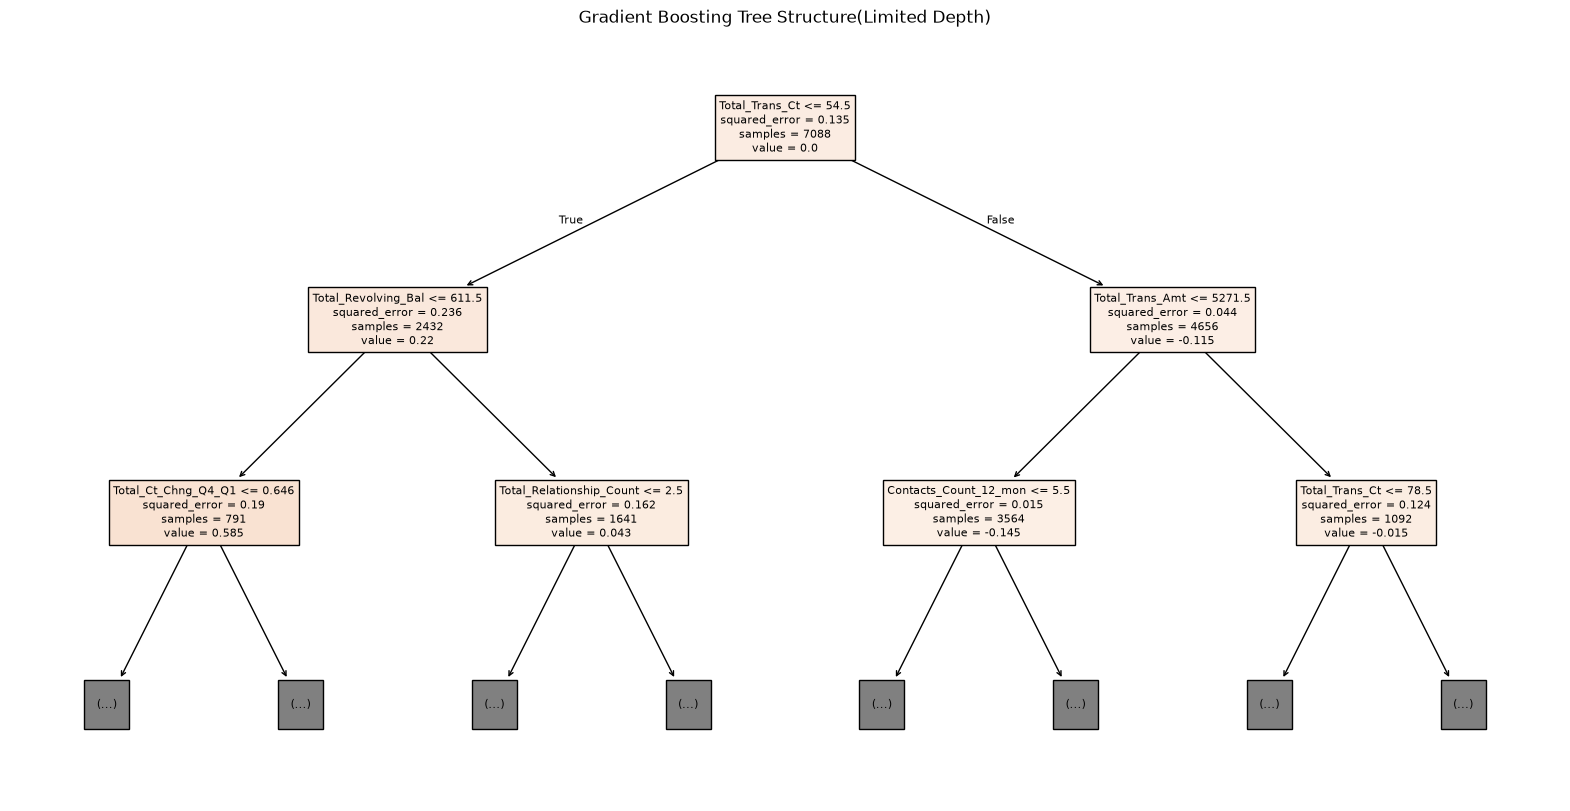

In [71]:
plt.figure(figsize=(20, 10))    
plot_tree(gb_model.estimators_[0, 0], filled=True, feature_names=X.columns, class_names=['Existing Customer', 'Attrited Customer'], max_depth=2)
plt.title("Gradient Boosting Tree Structure(Limited Depth)")
plt.show()

This code visualizes the first shallow decision tree used by the Gradient Boosting model:

```python
plt.figure(figsize=(20, 10))
plot_tree(
    gb_model.estimators_[0, 0],
    filled=True,
    feature_names=X.columns,
    class_names=['Existing Customer', 'Attrited Customer'],
    max_depth=2
)
plt.title("Gradient Boosting Tree Structure (Limited Depth)")
plt.show()
```

- `gb_model.estimators_[0, 0]` selects the first tree for the first class.
- `filled=True` colors nodes according to their predicted class.
- `feature_names=X.columns` displays the feature used at each split.
- `class_names` labels the customer classes.
- `max_depth=2` shows only the first two levels for readability.
- This displays one component tree, not the complete Gradient Boosting model. The final prediction combines the contributions of all sequential trees.

## *Model Comparison & final Model Selection* 

In [72]:
model_eval_results

,Model,Train_Accuracy,Train_Precision,Train_Recall,Test_F1,Test_Accuracy,Test_Precision,Test_Recall,Test_F1
0,Decision Tree,1.000000,1.000000,1.000000,1.000000,0.933202,0.795031,0.786885,0.790937
1,Random Forest,1.000000,1.000000,1.000000,1.000000,0.954590,0.914692,0.790984,0.848352
2,Gradient Boosting,0.977003,0.956075,0.898156,0.926211,0.959197,0.929245,0.807377,0.864035
3,Gradient Boosting,0.977003,0.956075,0.898156,0.926211,0.959197,0.929245,0.807377,0.864035


 compares the three classifiers using training and testing metrics:

- **Accuracy:** Overall percentage of correct predictions.
- **Precision:** Of customers predicted as attrited, how many truly attrited.
- **Recall:** Of all truly attrited customers, how many the model detected.
- **F1-score:** Balance between precision and recall.
- **Train metrics:** Performance on data used to fit the model.
- **Test metrics:** Performance on unseen data and the most important for model selection.

For churn prediction, prioritize **Test Recall and Test F1**, because missing a customer likely to churn can be costly. A large difference between train and test scores indicates overfitting.

There is currently a column-definition issue: `Test_F1` appears twice, `Test_Recall` has a trailing space, and `Train_F1` is missing. The intended columns should be:

```python
[
    'Model', 'Train_Accuracy', 'Train_Precision', 'Train_Recall',
    'Train_F1', 'Test_Accuracy', 'Test_Precision',
    'Test_Recall', 'Test_F1'
]
```

The best model is generally the one with the strongest test F1 and recall while maintaining a small train-test performance gap.